### duam사이트에서 뉴스 정보를 읽어 텍스트 파일로 저장 후 유사도 확인하기
- 형태소 분석, Word2Vec, 유사도 분석 ....

In [4]:
!pip install konlpy # 형태소 분석
!pip install gensim
!pip install koreanize_matplotlib

In [5]:
from IPython.lib.security import encode
import pandas as pd
from konlpy.tag import Okt
okt = Okt()

with open('duam_news.txt','r',encoding='utf-8') as f:
    lines = f.read().splitlines()

# print(lines)
word_freq = {} # 명사만 추출해 기억
for line in lines:
  nouns = [word for word, tag in okt.pos(line) if tag=='Noun' and len(word) > 1]
  # print(nouns)
  for noun in nouns:
    word_freq[noun] = word_freq.get(noun, 0) + 1
# print(word_freq)

# 단어 건수별 내림차순 정렬해 DataFrame에 저장
sort_data = sorted(word_freq.items(), key=lambda two:(-two[1], two[0]))
# print(sort_data)
df = pd.DataFrame(sort_data, columns=['단어','빈도수'])
# print(df.head(10))

# df - csv로 저장
df.to_csv('nlp2word.csv', index=False, encoding='utf-8-sig')

df2 = pd.read_csv('nlp2word.csv', encoding='utf-8')
print(df2)

      단어  빈도수
0     한국   15
1     오픈   12
2     알트   11
3    카카오   10
4     기업    9
..   ...  ...
198   허용    1
199   혁신    1
200   현장    1
201   활용    1
202  회동할    1

[203 rows x 2 columns]


In [6]:
from numpy import negative
from os.path import join
from os import write
# 유사도 확인하기
# 원본 파일에서 명사, 동사 추출
with open('nlp2word_frq.txt','w',encoding='utf-8') as fi:
  for line in lines:
    tokens = okt.pos(line, stem=True, ) # stem=True 동사 원형으로 출력
    words = [word for word, tag in tokens if tag in ['Noun','Verb'] and len(word) > 1]
    if words:
      fi.write(' '.join(words) + '\n')

from gensim.models import word2vec

# LineSentence : 텍스트를 한줄 씩 읽어 단어 리스트로 변환
sentences = word2vec.LineSentence('nlp2word_frq.txt')
print(sentences)

model = word2vec.Word2Vec(sentences=sentences, vector_size=100, window=10, min_count=1, sg=1)
print(model)

# 학습된 모델 저장
model.save('nlp2model.model')

# 저장된 모델 읽기
model = word2vec.Word2Vec.load('nlp2model.model')
print(model.wv.index_to_key[:5])
print('은행' in model.wv.key_to_index)
print('카카오' in model.wv.key_to_index)

print('카카오와 유사한 단어 출력')
print(model.wv.most_similar('카카오'))
print('앤트로픽과 유사한 단어 출력')
print(model.wv.most_similar('앤트로픽'))
print()

# 두 단어의 벡터를 더한 결과에 가장 가까운 단어
print(model.wv.most_similar(positive=['앤트로픽','정부']))
print(model.wv.most_similar(positive=['앤트로픽','정부'], negative=['한국']))


Word2Vec<vocab=232, vector_size=100, alpha=0.025>
['하다', '한국', '오픈', '알트', '카카오']
False
True
카카오와 유사한 단어 출력
[('정부', 0.514797568321228), ('기업', 0.47375667095184326), ('데이터', 0.47275975346565247), ('전략', 0.47159454226493835), ('방한', 0.4594379663467407), ('하다', 0.4575585126876831), ('외부', 0.45327380299568176), ('전자', 0.4530821740627289), ('한국', 0.44634515047073364), ('협력', 0.4422210454940796)]
앤트로픽과 유사한 단어 출력
[('전자', 0.544661283493042), ('회장', 0.5212864875793457), ('하다', 0.5181979537010193), ('한국', 0.5175204277038574), ('삼성', 0.5121911764144897), ('기업', 0.49778711795806885), ('네이버', 0.49732062220573425), ('클로드', 0.4840635657310486), ('직원', 0.46604615449905396), ('엔터프라이즈', 0.4642605185508728)]

[('전자', 0.621496856212616), ('한국', 0.574964702129364), ('카카오', 0.5561976432800293), ('삼성', 0.5382905006408691), ('하다', 0.5264995694160461), ('클로드', 0.5123706459999084), ('협력', 0.5107249021530151), ('기업', 0.5102964043617249), ('회장', 0.49775221943855286), ('외부', 0.48883187770843506)]
[('전자', 0.4069131

[('전자', 0.544661283493042), ('회장', 0.5212864875793457), ('하다', 0.5181979537010193), ('한국', 0.5175204277038574), ('삼성', 0.5121911764144897), ('기업', 0.49778711795806885), ('네이버', 0.49732062220573425), ('클로드', 0.4840635657310486), ('직원', 0.46604615449905396), ('엔터프라이즈', 0.4642605185508728)]
words : ['앤트로픽', '전자', '회장', '하다', '한국', '삼성', '기업', '네이버', '클로드', '직원', '엔터프라이즈']
reduced_vectors : [-0.01008911  0.00347913]


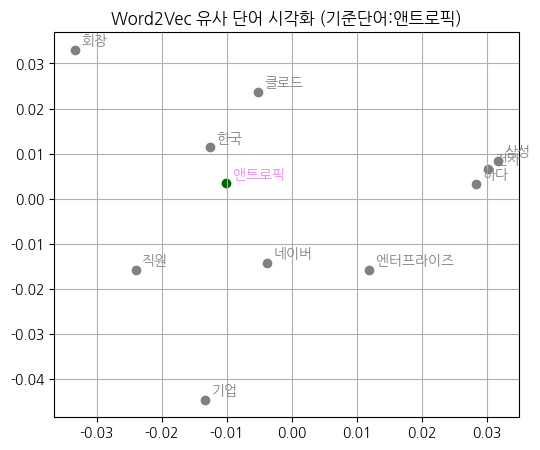

In [7]:
# 시각화 - 유사도 기반 단어간 관계
from matplotlib import pyplot as plt
import koreanize_matplotlib
from sklearn.decomposition import PCA
import platform # 환경 정보 확인용

target_word = '앤트로픽'

similar_words = model.wv.most_similar(target_word, topn=10)
print(similar_words)

# 단어 리스트 작성
words = [target_word] + [word for word, _ in similar_words]
print('words :',words) # ['앤트로픽', '전자', '회장',...

# 단어 벡터 추출
word_vectors = [model.wv[word] for word in words]
# print('word_vectors :', word_vectors)

# 의미는 유지한채로 차원 축소 - PCA 사용
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)
print('reduced_vectors :', reduced_vectors[0])

plt.figure(figsize=(6, 5))
for i, word in enumerate(words):
  x, y = reduced_vectors[i]
  plt.scatter(x, y, color='darkgreen' if i == 0 else 'gray')
  plt.text(x+0.001, y+0.001, word, fontsize=10, color='violet' if i == 0 else 'gray')
plt.title(f'Word2Vec 유사 단어 시각화 (기준단어:{target_word})')
plt.grid(True)
plt.show()

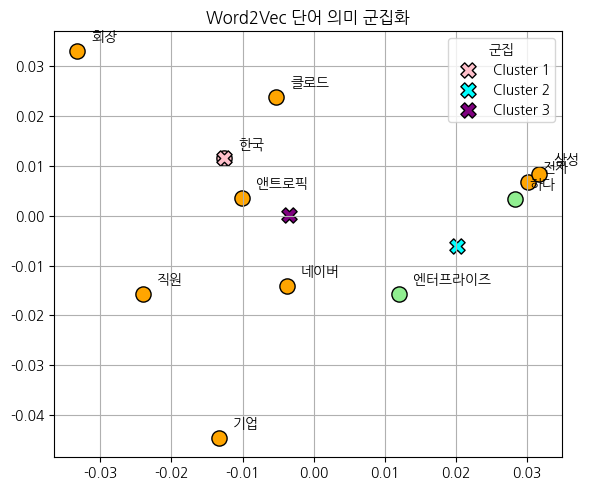

Cluster 3 : 앤트로픽, 전자, 회장, 삼성, 기업, 네이버, 클로드, 직원
Cluster 2 : 하다, 엔터프라이즈
Cluster 1 : 한국


In [20]:
# 단어들을 의미적으로 군집화
from sklearn.cluster import KMeans
# print(model.wv.key_to_index)
filtered_words = [word for word in words if word in model.wv.key_to_index]
# print(filtered_words)

# 단어 벡터 추출
word_vectors = [model.wv[word] for word in filtered_words]
# print(word_vectors)
vectors = [model.wv[word] for word in filtered_words]
# print(vectors) # 고차원공간에 저장하기 위해 벡터화

# K-Means Clustering 진행
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(vectors)

# PCA로 차원 축고
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)
centers = pca.transform(kmeans.cluster_centers_)

colors = ['pink','lightgreen','orange','purple','aqua']

plt.figure(figsize=(6, 5))
for i, word in enumerate(filtered_words):
  x, y = reduced_vectors[i]
  plt.scatter(x, y, color=colors[labels[i]], s=120, edgecolor='black')
  plt.text(x + 0.002, y + 0.002, word, fontsize=10)

# cluster 중심점 표현
for i ,(cx, cy) in enumerate(centers):
  plt.scatter(cx, cy, color=colors[-i], s=120, marker='X', edgecolor='black', label=f'Cluster {i + 1}')

plt.title('Word2Vec 단어 의미 군집화')
plt.legend(title='군집')
plt.grid(True)
plt.tight_layout()
plt.show()

# 군집별 단어 리스트 출력
from collections import defaultdict

cluster_dict = defaultdict(list)
for word, label in zip(filtered_words, labels):
  cluster_dict[label].append(word)
# print(cluster_dict)

for cid, word_list in cluster_dict.items():
  print(f'Cluster {cid + 1} : {", ".join(word_list)}')


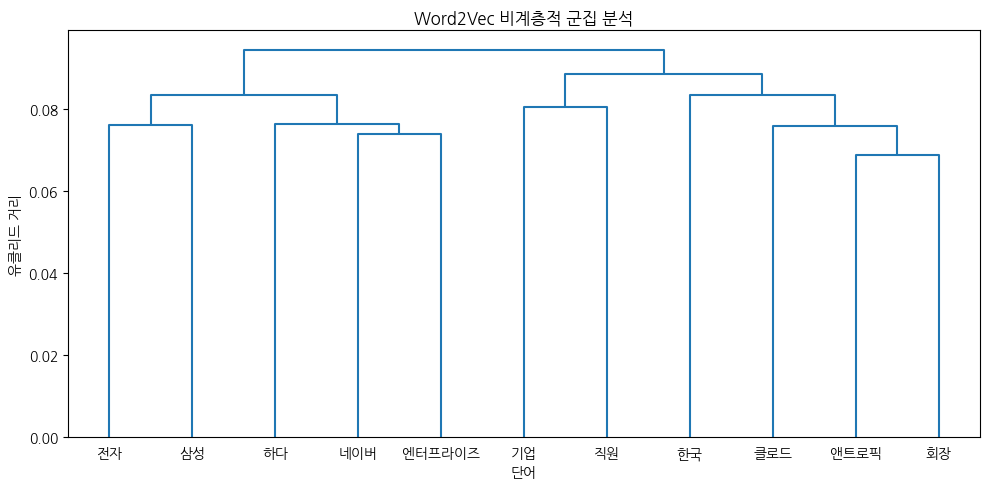

In [23]:
# 계층적 군집 분석  - 덴드로그램
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
vectors = np.array([model.wv[word] for word in filtered_words])

linkage_metrix = linkage(vectors, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_metrix, labels=filtered_words, leaf_font_size=10)
plt.title('Word2Vec 비계층적 군집 분석')
plt.xlabel('단어')
plt.ylabel('유클리드 거리')
plt.tight_layout()
plt.show()